Episode 50, avg reward last 50: -223.6
Episode 100, avg reward last 50: -75.9
Episode 150, avg reward last 50: -49.4
Episode 200, avg reward last 50: -34.7
Episode 250, avg reward last 50: -30.9
Episode 300, avg reward last 50: -22.3
Episode 350, avg reward last 50: -21.7
Episode 400, avg reward last 50: -22.2
Episode 450, avg reward last 50: -21.0
Episode 500, avg reward last 50: -21.8


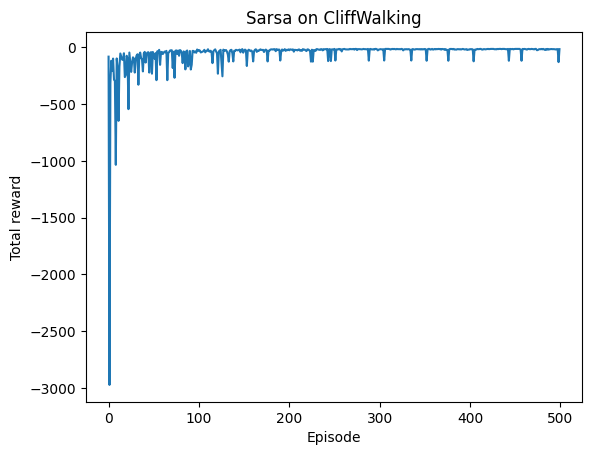

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make('CliffWalking-v0')
n_actions = env.action_space.n
n_states = env.observation_space.n

# Khởi tạo Q table
Q = np.zeros((n_states, n_actions))

# Tham số
alpha = 0.1   # learning rate
gamma = 0.99  # discount
epsilon = 0.1 # exploration
episodes = 500

def epsilon_greedy(state, epsilon):
    if np.random.random() < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(Q[state, :])

rewards_per_episode = []

for ep in range(episodes):
    state, _ = env.reset()
    action = epsilon_greedy(state, epsilon)
    done = False
    total_reward = 0
    while not done:
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_action = epsilon_greedy(next_state, epsilon) if not done else None
        # Cập nhật Sarsa
        target = reward + gamma * (Q[next_state, next_action] if not done else 0)
        Q[state, action] += alpha * (target - Q[state, action])
        state, action = next_state, next_action
        total_reward += reward
    rewards_per_episode.append(total_reward)
    if (ep+1) % 50 == 0:
        print(f"Episode {ep+1}, avg reward last 50: {np.mean(rewards_per_episode[-50:]):.1f}")

# Vẽ
plt.plot(rewards_per_episode)
plt.xlabel('Episode')
plt.ylabel('Total reward')
plt.title('Sarsa on CliffWalking')
plt.show()